# Preparation checks for the HQCI tutorial at VIS 2026

The below code will check whether your preparation is done. If you run into no error, you're good to go. If not and you have hard time fixing it, please contact us. 

## Part 1: Offline settings

If you are not going to run your code on an actual machine, you just need to complete this part.

In [8]:
import qiskit
import matplotlib
import revkit
import qiskit_aer
import altair
from qiskit.transpiler import generate_preset_pass_manager
from qiskit_ibm_runtime.fake_provider import FakeSherbrooke

In [2]:
qiskit.__version__

'2.5.2'

### Compose and draw

Matplotlib is building the font cache; this may take a moment.


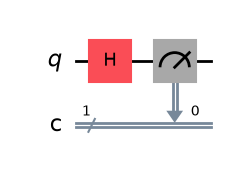

In [3]:
qc = qiskit.QuantumCircuit(1,1)
qc.h(0)
qc.measure([0], [0])
qc.draw("mpl")

### Transpilation with a fake machine

In [4]:
backend = FakeSherbrooke()
pass_manager = generate_preset_pass_manager(
    optimization_level=3, backend=backend
)

In [5]:
transpiled = pass_manager.run(qc)

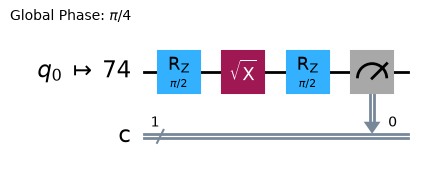

In [6]:
transpiled.draw("mpl", idle_wires=False)

### Simulator

In [9]:
from qiskit_aer import AerSimulator

In [10]:
backend_sim = AerSimulator.from_backend(backend)

In [12]:
job = backend_sim.run(transpiled, shots=1024)
result = job.result()

In [15]:
result.get_counts()

{'1': 523, '0': 501}

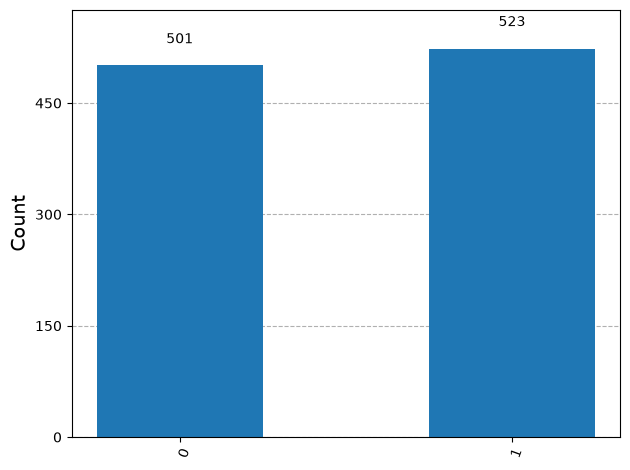

In [16]:
from qiskit.visualization import plot_histogram
plot_histogram(result.get_counts())

## Part 2: Online settings
If you are going to run your code on an actual machine, then you'll need to complete this part.
This part will not use any charged resources from IBM Cloud.

In [17]:
from qiskit_ibm_runtime import QiskitRuntimeService
import os

In [12]:
# # If you wish to save your api key using this command.
# # Once you're done, remove this cell before uploading somewhere (e.g., github).
# QiskitRuntimeService.save_account(token="<your-api-key-here>", overwrite=True)

In [18]:
def get_api_key(env_var_name=None, ext_file_path=None):
    my_token = None
    if env_var_name is not None:
        my_token = os.environ.get(env_var_name)
        QiskitRuntimeService.save_account(token=my_token, overwrite=True)
    elif ext_file_path is not None:
        with open(ext_file_path, "r") as f:
            my_token = f.read()
            QiskitRuntimeService.save_account(token=my_token, overwrite=True)
    else:
        print("You saved it, right?")

# # if you saved it as am environment variable, then provide the name.
# get_api_key(env_var_name="<VAR_NAME>")
# # if you saved it in a text file, then provide the path.
# get_api_key(ext_file_path="<FILE_PATH>")

In [19]:
service = QiskitRuntimeService(
    channel="ibm_quantum_platform",
    # instance="<your CRN key optional>"
)
# CRN is available via: https://quantum.cloud.ibm.com/instances
# the below warning message is fine!

qiskit_runtime_service.__init__:WARNING:2026-09-19 20:38:55,357: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService(). Alternatively, pass instance='auto' or save it to your account for auto-selection without warning.


In [20]:
# get instance information
backend_real = service.least_busy(simulator=False, operational=True)
backend_real

qiskit_runtime_service.backends:WARNING:2026-09-19 20:38:56,032: Loading instance: open-instance, plan: open
qiskit_runtime_service.backends:WARNING:2026-09-19 20:38:59,687: Using instance: open-instance, plan: open


<IBMBackend('ibm_marrakesh')>

In [21]:
pass_manager_real = generate_preset_pass_manager(
    optimization_level=3, backend=backend_real
)

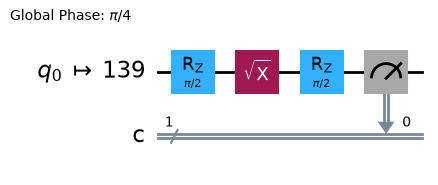

In [22]:
transpiled2 = pass_manager_real.run(qc)
transpiled2.draw("mpl", idle_wires=False)